# **Part 1: Visualization & Exploratory Data Analysis (EDA)**

### **Dataset Introduction**

In this project, we will work with the Palmer Penguins dataset, which contains measurements of penguins observed on islands near Antarctica.

Please download the dataset [penguins.csv](https://drive.google.com/file/d/1dv8A8v_sdf29p1At40S7KBslJPmBA3e9/view?usp=sharing) or from canvas.

### **Dataset Description**

Each row represents a penguin, and columns include:

- species – Penguin species
- island – Island where the penguin was found
- bill_length_mm – Bill length (mm)
- bill_depth_mm – Bill depth (mm)
- flipper_length_mm – Flipper length (mm)
- body_mass_g – Body mass (grams)
- sex – Sex of the penguin

Some values are missing, which makes this dataset ideal for practicing missing data handling.



Your task is to perform a comprehensive Exploratory Data Analysis (EDA) and visualization on the Palmer Penguins dataset. This project aims to deepen your understanding of data characteristics, relationships between variables, and effective data presentation using Python's data science libraries.

**Instructions:**

1.  **Load the Dataset:** Begin by loading the `penguins.csv` dataset into a pandas DataFrame.
2.  **Initial Data Inspection:** Perform an initial inspection to understand the dataset's structure. Display the first few rows, check data types and non-null values, and generate descriptive statistics.
3.  **Handle Missing Values:** Identify and address any missing values in the dataset. Clearly explain your chosen strategy for handling missing data (e.g., imputation, dropping rows/columns) and justify your decision.
4.  **Perform EDA and Visualization:** Conduct a thorough EDA, exploring distributions, relationships, and patterns within the data. You are required to use **at least three distinct types of visualizations** (e.g., histograms, scatter plots, box plots, bar charts). For each visualization:
    *   Justify your choice of plot type, explaining why it is suitable for the variables being analyzed.
    *   Clearly articulate what insights each visualization reveals about the data (e.g., distributions, correlations, outliers, group differences).
5.  **Summarize Key Findings:** Based on your EDA and visualizations, summarize the most important insights and observations about the Palmer Penguins dataset. Highlight any discovered patterns, trends, anomalies, or interesting relationships.
6.  **Final Task:** Present your complete EDA and visualization analysis, emphasizing key takeaways and interpretations of the observed data characteristics and relationships in a clear and concise manner.

In [2]:
import pandas as pd
df = pd.read_csv("penguins.csv")

In [3]:
print(df.head(5))

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  


In [4]:
print(df.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


# Handling Missing Values

I dropped null values by row because...

1. There are only 8 rows with at least one missing values. Dropping 8 rows still leaves 334 data points, so there is no need to impute.

2. Dropping by row keeps important columns, whereas dropping by column would remove most of them. Calling `df.dropna(axis=1)` gets rid of all but 2 columns because only 2 columns have no missing values. In contrast, if we get rid of the 8 rows, we preserve more data.

Therefore, `df.dropna(axis=0)` is the best option for handling the missing values in this dataset. It preserves data and is simpler than imputation.

In [6]:
df = df.dropna(axis=0)

# Exploratory Data Analysis (EDA)

Firstly, I analyzed bill length across penguin species with a bar chart. A bar chart is the most appropriate choice because it can show how a categorical variable is related to a numeric variable. In this case, I explored the relationship between `species` (a categorical variable) and the average value of `bill_length_mm` grouped by species (a numeric variable).

Next, I used a scatter plot to graph the relationship between `bill_length_mm` and `flipper_length_mm`. In this case, both variables are numeric, so a scatter plot makes the most sense. Also, `plt.scatter()` is more approriate than `plt.plot()` because Matplotlib's `plt.plot()` function assumes that there is a functionally dependent relationship between the variables we plot. Since rows that have the same value for `bill_length_mm` might have different values for `flipper_length_mm`, we cannot assume that there is a functional dependence between the two variables. Thus, a scatter plot is the most suitable option.

Lastly, I explored the distribution of penguin masses by using a histogram. The variable `penguin_mass_g` is numerical and can be binned into discrete intervals, so a histogram is the best way to visualize the data.

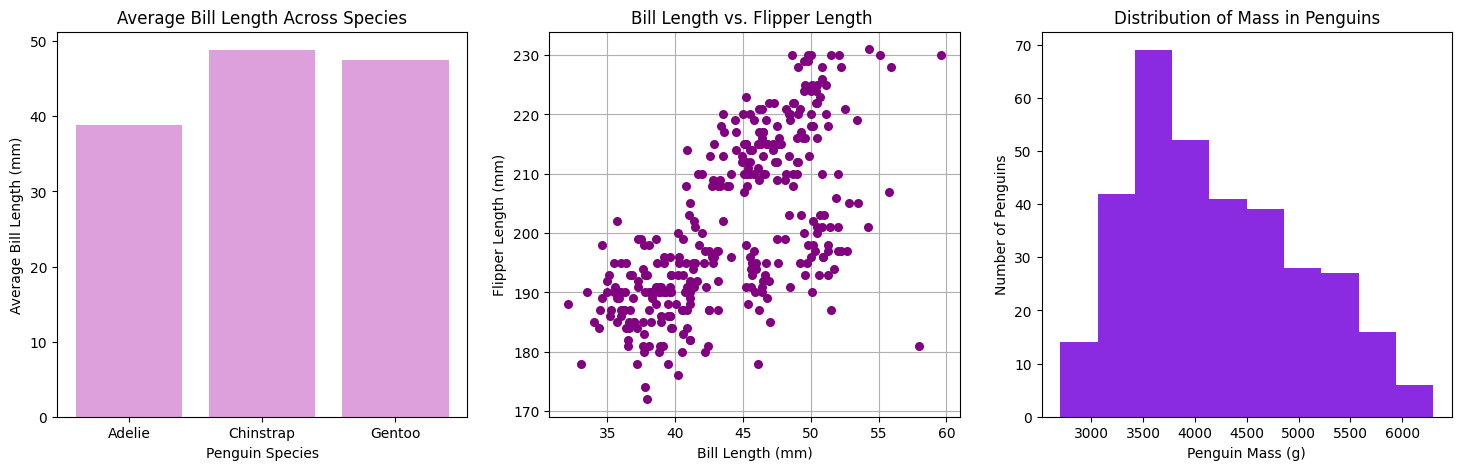

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

bill_length = df.groupby("species")["bill_length_mm"].mean().to_frame().reset_index()
axes[0].bar(bill_length["species"], bill_length["bill_length_mm"], color="plum")
axes[0].set_xlabel("Penguin Species")
axes[0].set_ylabel("Average Bill Length (mm)")
axes[0].set_title("Average Bill Length Across Species")

axes[1].grid()
axes[1].set_axisbelow(True)
axes[1].scatter(df["bill_length_mm"], df["flipper_length_mm"], color="purple", s=30)
axes[1].set_xlabel("Bill Length (mm)")
axes[1].set_ylabel("Flipper Length (mm)")
axes[1].set_title("Bill Length vs. Flipper Length ")

axes[2].hist(df['body_mass_g'], color='blueviolet')
axes[2].set_xlabel("Penguin Mass (g)")
axes[2].set_ylabel("Number of Penguins")
axes[2].set_title("Distribution of Mass in Penguins")

plt.show()

# Key Findings

The first graph ("Average Bill Length Across Species") shows that...
*   Chinstrap penguins have the highest average bill length (\~48 mm) followed by gentoo penguins (\~47 mm) and adelie penguins (\~38 mm).
*   Chinstrap and gentoo penguins have similar bill lengths, while adelie penguins have noticeably smaller bills.

The second graph ("Bill Length vs. Flipper Size") shows that...
*   There is a weak, positive linear correlation between the variables `bill_length_mm` and `flipper_length_mm`. This suggests that penguins with longer bills tend to have longer flippers.

The third graph ("Distribution of Mass in Penguins") shows that...
* Most penguins (\~50% of them) have a mass between 3500 and 4000 g.
* Penguin masses are skewed to the right, meaning that penguins tend to be below the median weight rather than above it.